# 0 Processing

### Load and imports

In [3]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Metrics / Utilities
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Notebook Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [4]:
#Load Preprocessed Dataset
df = pd.read_csv(
    "../final_dfs/full_df_preprocessed.csv",
    parse_dates=["timestamp"]
)

print(df.shape)

df.head()

(11520, 15)


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_score,is_cognitive,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,2026-06-03 00:00:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
1,2026-06-03 00:01:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,73.0,0,False,False,False,True,False,False,False,False
3,2026-06-03 00:03:00,21.0,32.0,14.91,74.0,73.0,0,True,False,False,False,False,False,False,False
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,73.0,0,False,False,True,False,False,False,False,False


In [5]:
print(df["timestamp"].min())
print(df["timestamp"].max())
print(len(df))

2026-06-03 00:00:00
2026-06-10 23:59:00
11520


In [6]:
expected = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="1min"
)

print("Expected:", len(expected))
print("Actual  :", len(df))

Expected: 11520
Actual  : 11520


### Configurations

In [8]:
# False -> use current 8-day dataset (4-2-2 split)
# True  -> use future 14-day dataset (10-2-2 split)

FULL_DATA = False

In [9]:
df.dtypes

timestamp                  datetime64[ns]
stress                            float64
body_battery                      float64
respiration_rate                  float64
heart_rate                        float64
sleep_score                       float64
is_cognitive                        int64
activity_type_generic                bool
activity_type_running                bool
activity_type_sedentary              bool
activity_type_unknown                bool
activity_type_walking                bool
sleep_level_deep                     bool
sleep_level_light                    bool
sleep_level_rem                      bool
dtype: object

### Train-Val-Test Split

In [11]:
def temporal_train_val_test_split(df, full_data=False):
    """
    Chronological train/val/test split by whole days.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing a timestamp column.
    full_data : bool
        False -> 4-2-2 split (8 days)
        True  -> 10-2-2 split (14 days)

    Returns
    -------
    train_df, val_df, test_df
    """

    df = df.sort_values("timestamp").copy()

    unique_days = sorted(df["timestamp"].dt.date.unique())

    if full_data:
        train_days = unique_days[:10]
        val_days = unique_days[10:12]
        test_days = unique_days[12:14]
    else:
        train_days = unique_days[:4]
        val_days = unique_days[4:6]
        test_days = unique_days[6:8]

    train_df = df[
        df["timestamp"].dt.date.isin(train_days)
    ].copy()

    val_df = df[
        df["timestamp"].dt.date.isin(val_days)
    ].copy()

    test_df = df[
        df["timestamp"].dt.date.isin(test_days)
    ].copy()

    print("=" * 50)
    print("TEMPORAL SPLIT")
    print("=" * 50)

    print("\nTrain Days:")
    print(list(train_days))

    print("\nValidation Days:")
    print(list(val_days))

    print("\nTest Days:")
    print(list(test_days))

    print("\nRows")
    print(f"Train: {len(train_df):,}")
    print(f"Val  : {len(val_df):,}")
    print(f"Test : {len(test_df):,}")

    print("\nPositive Class Ratio")
    print(f"Train: {train_df['is_cognitive'].mean():.3f}")
    print(f"Val  : {val_df['is_cognitive'].mean():.3f}")
    print(f"Test : {test_df['is_cognitive'].mean():.3f}")

    return train_df, val_df, test_df

In [12]:
train_df, val_df, test_df = temporal_train_val_test_split(
    df,
    full_data=FULL_DATA
)

TEMPORAL SPLIT

Train Days:
[datetime.date(2026, 6, 3), datetime.date(2026, 6, 4), datetime.date(2026, 6, 5), datetime.date(2026, 6, 6)]

Validation Days:
[datetime.date(2026, 6, 7), datetime.date(2026, 6, 8)]

Test Days:
[datetime.date(2026, 6, 9), datetime.date(2026, 6, 10)]

Rows
Train: 5,760
Val  : 2,880
Test : 2,880

Positive Class Ratio
Train: 0.196
Val  : 0.094
Test : 0.182


In [13]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

train_df.head()

(5760, 15)
(2880, 15)
(2880, 15)


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_score,is_cognitive,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,2026-06-03 00:00:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
1,2026-06-03 00:01:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,73.0,0,False,False,False,True,False,False,False,False
3,2026-06-03 00:03:00,21.0,32.0,14.91,74.0,73.0,0,True,False,False,False,False,False,False,False
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,73.0,0,False,False,True,False,False,False,False,False


### Create X and y

In [15]:
def create_X_y_splits(
    train_df,
    val_df,
    test_df,
    target_col="is_cognitive",
    drop_cols=None
):
    """
    Create X/y splits from train, validation and test DataFrames.

    Parameters
    ----------
    train_df, val_df, test_df : pd.DataFrame
    target_col : str
        Target column name.
    drop_cols : list or None
        Additional columns to drop from X.

    Returns
    -------
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
    """

    if drop_cols is None:
        drop_cols = ["timestamp"]

    X_train = train_df.drop(
        columns=[target_col] + drop_cols
    ).copy()

    y_train = train_df[target_col].copy()

    X_val = val_df.drop(
        columns=[target_col] + drop_cols
    ).copy()

    y_val = val_df[target_col].copy()

    X_test = test_df.drop(
        columns=[target_col] + drop_cols
    ).copy()

    y_test = test_df[target_col].copy()

    print("X_train:", X_train.shape)
    print("X_val  :", X_val.shape)
    print("X_test :", X_test.shape)

    return (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

In [16]:
(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
) = create_X_y_splits(
    train_df,
    val_df,
    test_df
)

X_train: (5760, 13)
X_val  : (2880, 13)
X_test : (2880, 13)


In [17]:
X_train

,stress,body_battery,respiration_rate,heart_rate,sleep_score,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,12.0,32.0,13.58,64.0,73.0,False,False,False,True,False,False,False,False
1,12.0,32.0,13.58,64.0,73.0,False,False,False,True,False,False,False,False
2,20.0,32.0,15.36,64.0,73.0,False,False,False,True,False,False,False,False
3,21.0,32.0,14.91,74.0,73.0,True,False,False,False,False,False,False,False
4,22.0,32.0,16.58,64.0,73.0,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5755,11.0,36.0,14.00,56.0,79.0,False,False,False,True,False,False,False,False
5756,12.0,37.0,14.16,57.0,79.0,False,False,False,True,False,False,False,False
5757,9.0,37.0,13.50,57.0,79.0,False,False,False,True,False,False,False,False
5758,13.0,37.0,14.08,57.0,79.0,False,False,False,True,False,False,False,False


### Normalization

In [19]:
from sklearn.preprocessing import StandardScaler

def scale_features(
    X_train,
    X_val,
    X_test,
    features_to_scale=None
):
    """
    Fit StandardScaler on training data only
    and apply to train/val/test.
    """

    if features_to_scale is None:
        features_to_scale = [
            "stress",
            "body_battery",
            "respiration_rate",
            "heart_rate",
            "sleep_score"
        ]

    scaler = StandardScaler()

    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    X_train[features_to_scale] = scaler.fit_transform(
        X_train[features_to_scale]
    )

    X_val[features_to_scale] = scaler.transform(
        X_val[features_to_scale]
    )

    X_test[features_to_scale] = scaler.transform(
        X_test[features_to_scale]
    )

    print("Scaled Features:")
    print(features_to_scale)

    return X_train, X_val, X_test, scaler

In [20]:
(
    X_train,
    X_val,
    X_test,
    scaler
) = scale_features(
    X_train,
    X_val,
    X_test
)

Scaled Features:
['stress', 'body_battery', 'respiration_rate', 'heart_rate', 'sleep_score']


In [21]:
X_train[[
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "sleep_score"
]].describe()

,stress,body_battery,respiration_rate,heart_rate,sleep_score
count,5.760000e+03,5.760000e+03,5.760000e+03,5.760000e+03,5.760000e+03
mean,-5.921189e-17,-1.628327e-16,-3.491035e-16,6.908054e-17,-1.144763e-15
std,1.000087e+00,1.000087e+00,1.000087e+00,1.000087e+00,1.000087e+00
min,-1.125973e+00,-1.674824e+00,-3.721991e+00,-1.599704e+00,-1.211397e+00
25%,-6.766881e-01,-8.577655e-01,-6.300823e-01,-7.602533e-01,-1.211397e+00
50%,-2.274035e-01,-8.876918e-02,4.109910e-02,-2.436683e-01,-1.750103e-01
75%,4.072109e-01,8.244140e-01,6.596514e-01,5.312093e-01,1.206839e+00
max,3.411801e+00,1.977909e+00,3.473073e+00,5.503340e+00,1.206839e+00


# 1 Traditional Models

In [23]:
from sklearn.ensemble import RandomForestClassifier

def run_random_forest(
    X_train,
    y_train,
    X_val,
    y_val
):

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    return evaluate_model(
        rf,
        X_train,
        y_train,
        X_val,
        y_val
    )

In [24]:
from xgboost import XGBClassifier

def run_xgboost(
    X_train,
    y_train,
    X_val,
    y_val
):

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )

    return evaluate_model(
        xgb,
        X_train,
        y_train,
        X_val,
        y_val
    )

In [25]:
from sklearn.naive_bayes import GaussianNB

def run_naive_bayes(
    X_train,
    y_train,
    X_val,
    y_val
):

    nb = GaussianNB()

    return evaluate_model(
        nb,
        X_train,
        y_train,
        X_val,
        y_val
    )

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

def evaluate_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val
):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    # Overall metrics
    results = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
    }

    print(type(model).__name__)
    print("-" * 40)

    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")

    # Awake-only metrics
    awake_mask = (
        ~X_val["sleep_level_deep"] &
        ~X_val["sleep_level_light"] &
        ~X_val["sleep_level_rem"]
    )

    y_val_awake = y_val[awake_mask]
    y_pred_awake = y_pred[awake_mask]

    awake_accuracy = accuracy_score(
        y_val_awake,
        y_pred_awake
    )

    print(f"\nAwake Accuracy: {awake_accuracy:.4f}")
    print(f"Awake Samples : {len(y_val_awake)}")

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred
    )

    plt.show()

    return model, results

### Baseline

RandomForestClassifier
----------------------------------------
Accuracy: 0.8833
Precision: 0.4046
Recall: 0.5185
F1: 0.4545

Awake Accuracy: 0.8431
Awake Samples : 2142


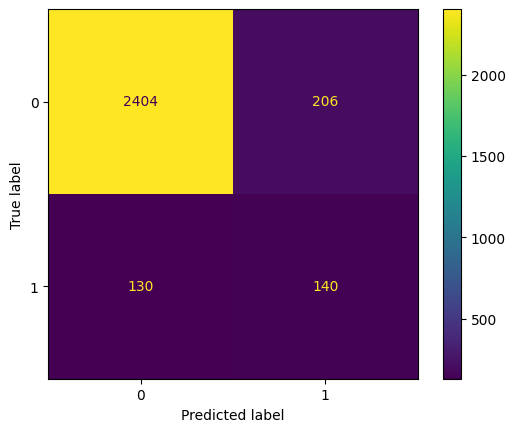

XGBClassifier
----------------------------------------
Accuracy: 0.8677
Precision: 0.3353
Recall: 0.4185
F1: 0.3723

Awake Accuracy: 0.8221
Awake Samples : 2142


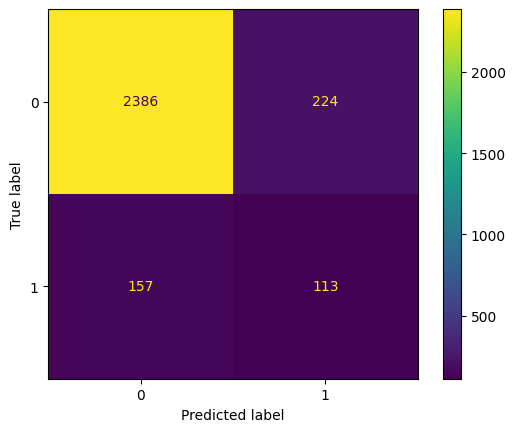

GaussianNB
----------------------------------------
Accuracy: 0.4472
Precision: 0.1450
Recall: 1.0000
F1: 0.2533

Awake Accuracy: 0.2568
Awake Samples : 2142


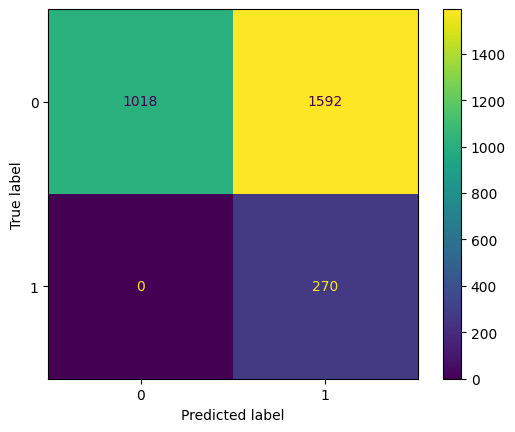

In [28]:
rf_model, rf_results = run_random_forest(
    X_train,
    y_train,
    X_val,
    y_val
)

xgb_model, xgb_results = run_xgboost(
    X_train,
    y_train,
    X_val,
    y_val
)

nb_model, nb_results = run_naive_bayes(
    X_train,
    y_train,
    X_val,
    y_val
)

# 2 Deep Learning Models